In [1]:
import os
import torch
from rtgym import RatatouGym
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from func import generate_circular_trajectories

In [3]:
temp_reso, spat_reso = 100, 1 # Temp reso: 100ms; Spatial reso: 1cm
gym = RatatouGym(temporal_resolution=temp_reso, spatial_resolution=spat_reso)

R_out, R_in = 17, 10
gym.init_arena_map(shape="loop", outer_radius=R_out, inner_radius=R_in)

vel_mean, vel_std = 2, 2
behavior_profile = {
                    "name":                   "random_explore",
                    "type":                   "predefined",
                    "velocity_mean":          vel_mean,
                    "velocity_sd":            vel_std,
                    "random_drift_magnitude": 0.05,
                    "switch_direction_prob":  0.05,
                    "switch_velocity_prob":   0.1,
                    'avoid_boundary_dist': 60
                    }

sensory_profile = {
                   "wsm": {
                          "type":     "weak_sm_cell",
                          "n_cells":   100,
                          "sigma":     15,
                          "magnitude": 4,
                          "normalize": True
                          },
                    }

# Set the sensory and behavior profiles
gym.set_sensory_from_profile(sensory_profile)
gym.set_behavior_from_profile(behavior_profile)

arena_map = gym.arena_map

time_pts = 100
traj = generate_circular_trajectories(arena_map, R_out, R_in, vel_mean, vel_std,
                    time_points=time_pts, batch_size=1000, visualize=False)

# Generate (Batch size) trial
gym.trial.new_trial(duration=0, external_traj=traj)

17 10 10
<class 'rtgym.trial.trial.Trajectory'>


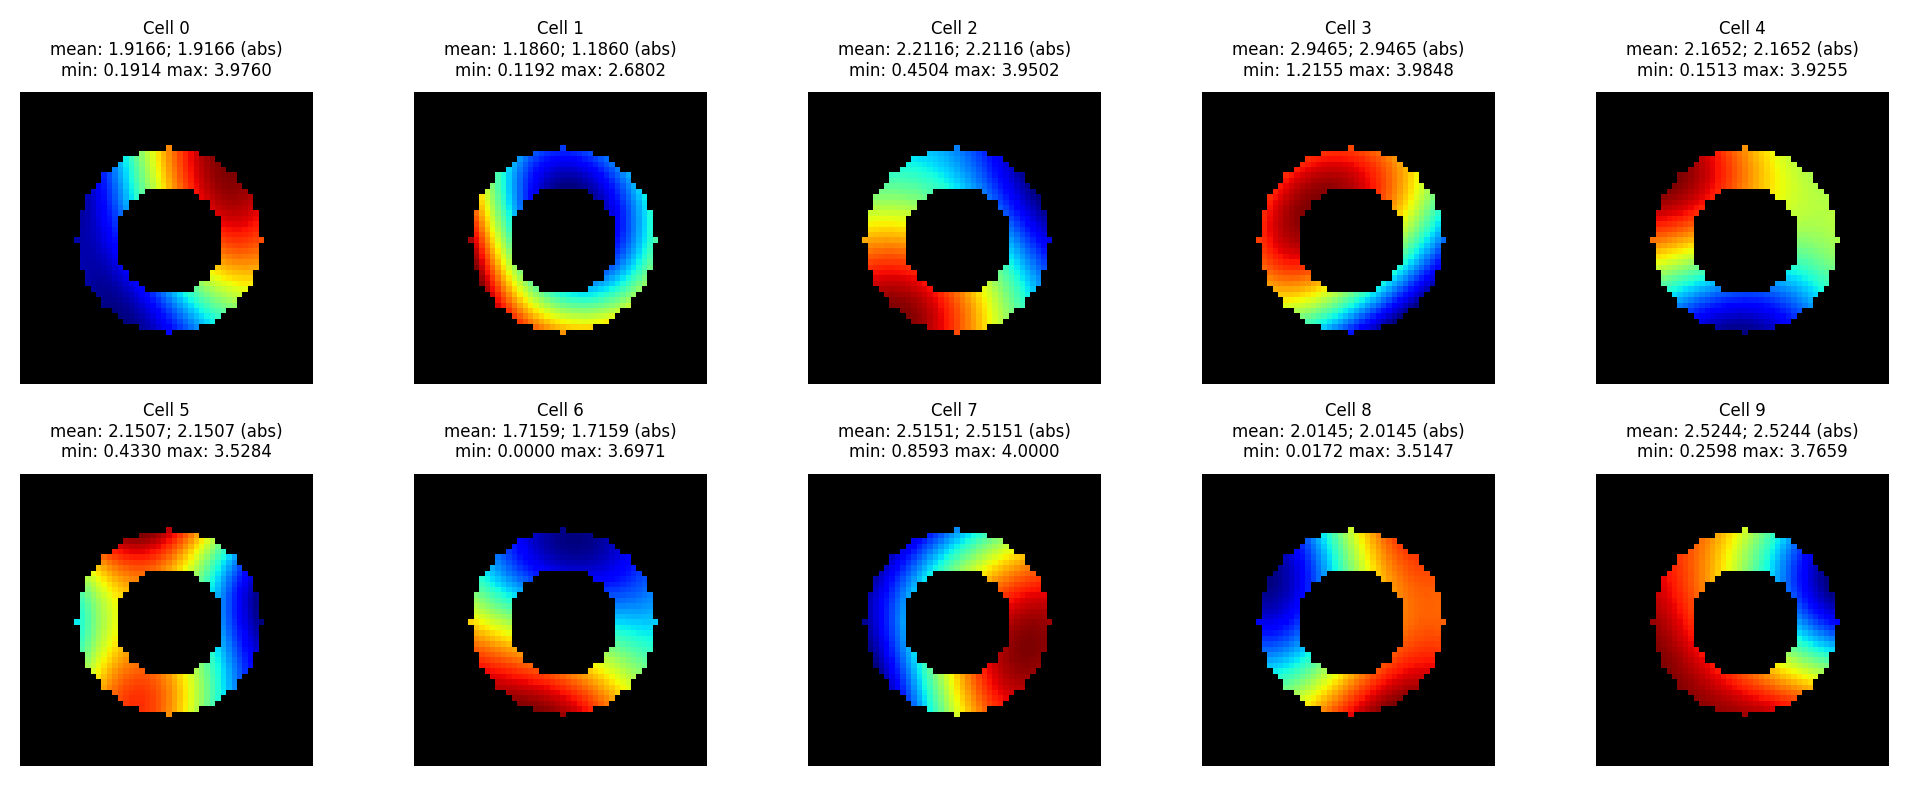

[(<Figure size 2000x800 with 10 Axes>,
  array([<Axes: title={'center': 'Cell 0\nmean: 1.9166; 1.9166 (abs)\nmin: 0.1914 max: 3.9760'}>,
         <Axes: title={'center': 'Cell 1\nmean: 1.1860; 1.1860 (abs)\nmin: 0.1192 max: 2.6802'}>,
         <Axes: title={'center': 'Cell 2\nmean: 2.2116; 2.2116 (abs)\nmin: 0.4504 max: 3.9502'}>,
         <Axes: title={'center': 'Cell 3\nmean: 2.9465; 2.9465 (abs)\nmin: 1.2155 max: 3.9848'}>,
         <Axes: title={'center': 'Cell 4\nmean: 2.1652; 2.1652 (abs)\nmin: 0.1513 max: 3.9255'}>,
         <Axes: title={'center': 'Cell 5\nmean: 2.1507; 2.1507 (abs)\nmin: 0.4330 max: 3.5284'}>,
         <Axes: title={'center': 'Cell 6\nmean: 1.7159; 1.7159 (abs)\nmin: 0.0000 max: 3.6971'}>,
         <Axes: title={'center': 'Cell 7\nmean: 2.5151; 2.5151 (abs)\nmin: 0.8593 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 8\nmean: 2.0145; 2.0145 (abs)\nmin: 0.0172 max: 3.5147'}>,
         <Axes: title={'center': 'Cell 9\nmean: 2.5244; 2.5244 (abs)\nmin: 0.25

In [4]:
gym.trial.vis_sensory()